# 🚕 NYC Taxi Data - Exploratory Data Analysis
The purpose of this notebook is to visualize trends and confirm the business anomalies detected by the automated `main.py` data quality script.

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chart settings
sns.set_theme(style="whitegrid")

# 1. Load data
df = pd.read_csv("data/yellow_tripdata_2021-01.csv", low_memory=False, nrows=100000)

# 2. Quick clean-up (removing logical errors identified in the report)
df_clean = df[
    (df["fare_amount"] > 0) & 
    (df["trip_distance"] > 0) & 
    (df["passenger_count"] > 0) & 
    (df["passenger_count"] <= 6)
].copy()

print(f"Data ready for analysis. Clean records count: {len(df_clean)}")

Data ready for analysis. Clean records count: 95982


/var/folders/f4/ggwrh4r54nngbvgmns0qh8v80000gn/T/ipykernel_76285/3554088275.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='passenger_count', palette="viridis")


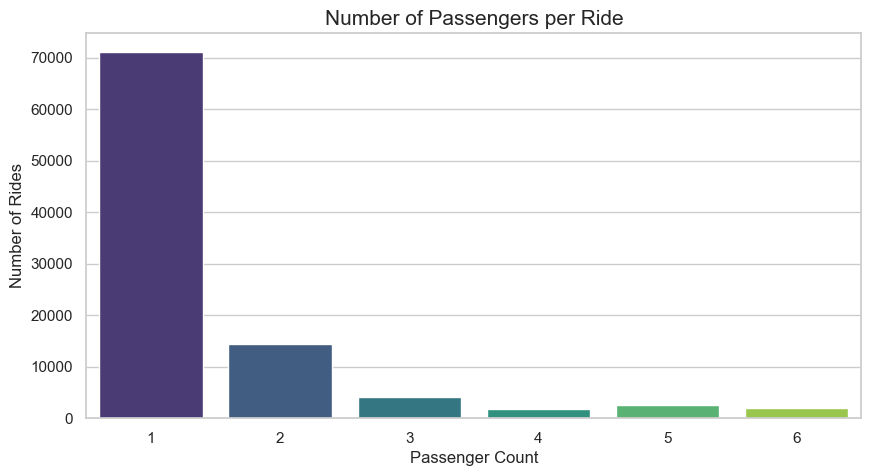

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='passenger_count', palette="viridis")

plt.title("Number of Passengers per Ride", fontsize=15)
plt.xlabel("Passenger Count")
plt.ylabel("Number of Rides")
plt.show()

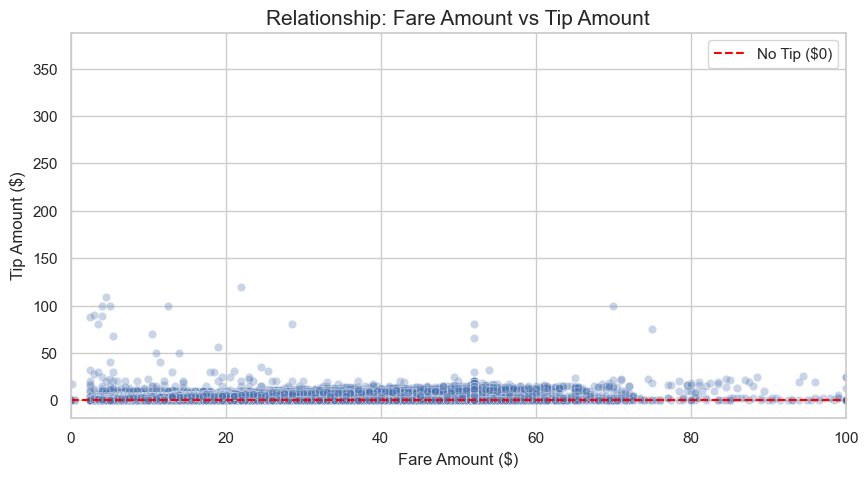

In [16]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='fare_amount', y='tip_amount', alpha=0.3)

# Red line indicating zero tip
plt.axhline(0, color='red', linestyle='--', label="No Tip ($0)") 
plt.xlim(0, 100) 

plt.title("Relationship: Fare Amount vs Tip Amount", fontsize=15)
plt.xlabel("Fare Amount ($)")
plt.ylabel("Tip Amount ($)")
plt.legend()
plt.show()

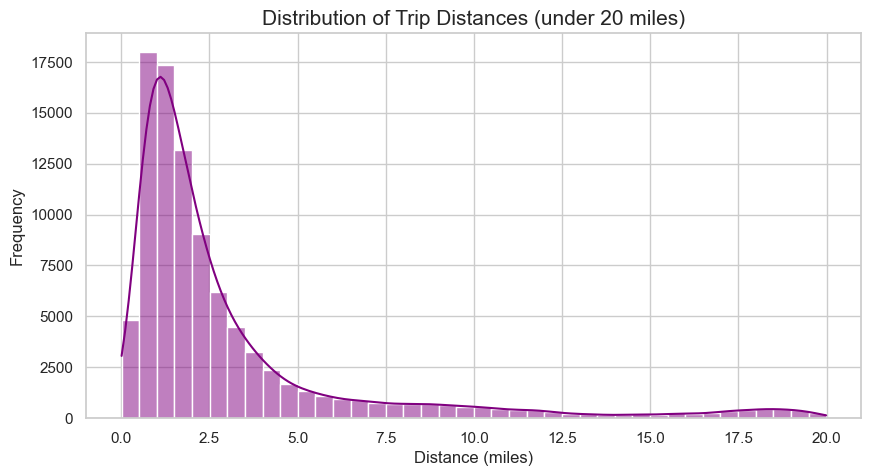

In [17]:
plt.figure(figsize=(10, 5))
# Filtering out extreme outliers just for better visualization
data_for_plot = df_clean[df_clean['trip_distance'] < 20]

sns.histplot(data=data_for_plot, x='trip_distance', bins=40, kde=True, color='purple')

plt.title("Distribution of Trip Distances (under 20 miles)", fontsize=15)
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()

---
## 🎯 Executive Summary & Business Recommendations

1. **Fleet Optimization:** With the overwhelming majority of rides serving single passengers, the fleet should prioritize smaller, fuel-efficient sedans over large vehicles.
2. **Revenue Tracking Anomalies:** The high volume of zero-tip rides on expensive fares ($30+) strongly suggests that a significant portion of cash tips is bypassing the system. This requires an audit of the payment logging application.
3. **Trip Characteristics:** Most trips are short-distance (under 3 miles). Pricing strategies and vehicle allocation should be optimized for short, quick turnovers in high-density areas.